# Lab 5 Tutorial:

From Bag-of-Words to Word2Vec (CBOW)

## Learning goals

By the end of this tutorial you should be able to:

1. Build a Bag-of-Words vector by hand and explain why it can't capture word-level meaning.
2. Load pretrained word vectors and use them for similarity search and vector-arithmetic analogies
   (`king - man + woman ≈ queen`), including visualising *why* the analogy works.
3. Explain what a word embedding is and why CBOW learns one.
4. Turn raw text into `(context, target)` training pairs for a chosen window size.
5. Derive and implement the CBOW forward pass (embedding lookup &rarr; average &rarr; linear &rarr; softmax).
6. Derive and implement the backward pass (cross-entropy gradient &rarr; `W2` gradient &rarr; `W1` gradient).
7. Understand why softmax needs to be computed in a numerically stable way.
8. Run a tiny end-to-end training loop and watch the loss go down on a toy sentence.
9. Use the trained embeddings to find nearest neighbours with cosine similarity.
10. Implement Skip-gram (the mirror-image architecture of CBOW) and understand how its forward/backward pass
    differs from CBOW's.

> **Important:** From Part C onward, the assignment asks you to implement every step yourself with plain
> NumPy — no `torch.nn.Embedding`, no `gensim.models.Word2Vec`. `gensim` is only used in Part B, to load
> *pretrained* vectors, not to train anything.


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)# this is taken so that we can assign W1 and W2 '0' at the begining or else after every cycle W1 and W2 will take a random values

## Part A: Bag-of-Words

Before dense embeddings, the simplest way to turn text into numbers is **Bag-of-Words (BoW)**: represent a
document as a vector of word counts over a fixed vocabulary. Word order and grammar are thrown away entirely
— all that survives is "which words appeared, and how many times."


In [2]:
bow_sentences = [
    "the king ruled the kingdom wisely",
    "the queen ruled the kingdom wisely",
    "the wizard cast a powerful spell",
]

bow_vocab = sorted(set(w for s in bow_sentences for w in s.lower().split()))
print("Vocabulary:", bow_vocab)


def build_bow_vector_demo(tokens, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    for t in tokens:
        if t in vocab:
            vec[vocab.index(t)] += 1
    return vec


bow_vecs = [build_bow_vector_demo(s.lower().split(), bow_vocab) for s in bow_sentences]
for s, v in zip(bow_sentences, bow_vecs):
    print(v, "<-", s)

Vocabulary: ['a', 'cast', 'king', 'kingdom', 'powerful', 'queen', 'ruled', 'spell', 'the', 'wisely', 'wizard']
[0 0 1 1 0 0 1 0 2 1 0] <- the king ruled the kingdom wisely
[0 0 0 1 0 1 1 0 2 1 0] <- the queen ruled the kingdom wisely
[1 1 0 0 1 0 0 1 1 0 1] <- the wizard cast a powerful spell


### Comparing documents with BoW cosine similarity

Even though BoW throws away grammar, it can still say "these two documents use similar words." The "king"
sentence and the "queen" sentence share every word except one, so we'd expect a high cosine similarity
between them — much higher than either has with the unrelated "wizard" sentence.


In [3]:
def bow_cosine_similarity_demo(v1, v2):
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)


sim_king_queen = bow_cosine_similarity_demo(bow_vecs[0], bow_vecs[1])
sim_king_wizard = bow_cosine_similarity_demo(bow_vecs[0], bow_vecs[2])

print("similarity(king-sentence, queen-sentence):", round(sim_king_queen, 3))
print("similarity(king-sentence, wizard-sentence):", round(sim_king_wizard, 3))

similarity(king-sentence, queen-sentence): 0.875
similarity(king-sentence, wizard-sentence): 0.289


In [4]:
king_vector = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])
queen_vector = np.array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

similarity = np.dot(king_vector, queen_vector) / (
    np.linalg.norm(king_vector) * np.linalg.norm(queen_vector)
)

print("Cosine similarity:", similarity)

Cosine similarity: 0.0


### Where Bag-of-Words breaks down

BoW can compare whole *documents* reasonably well when they share a lot of vocabulary. But look at the words
`king` and `queen` **on their own**, as one-hot vectors (each word gets its own independent dimension, with
no relation to any other dimension):

$$
\mathrm{cosine}(\text{one\_hot}(\text{king}),\ \text{one\_hot}(\text{queen})) = 0
$$

They are exactly **orthogonal** — as unrelated, geometrically, as `king` and `spaceship` would be. BoW /
one-hot representations have no mechanism to learn that `king` and `queen` are related concepts; every word
is its own isolated dimension. This is exactly the gap dense embeddings (Part B and Part C) are built to
close.


## Part B: Playing with Pretrained Word Vectors

Training genuinely good embeddings needs huge amounts of text — far more than we can train on in this course.
To see what *well-trained* dense embeddings can do, we load small pretrained vectors (**GloVe**, trained on
Wikipedia + Gigaword) with `gensim`, rather than training our own here.


In [6]:
# Downloads ~66MB the first time (cached afterwards). Requires internet access (e.g. Google Colab).
!pip install gensim
import gensim.downloader as glove_api

word_vectors_demo = glove_api.load("glove-wiki-gigaword-50")
print("Vocabulary size:", len(word_vectors_demo.index_to_key))
print("Vector for 'king' has shape:", word_vectors_demo["king"].shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 48.8 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
Vocabulary size: 400000
Vector for 'king' has shape: (50,)


### Similarity with real, dense vectors

Unlike the one-hot vectors from Part A, `word_vectors_demo.similarity(...)` gives a graded, meaningful score
&mdash; not just 0 or 1.


In [7]:
print("similarity(king, queen):   ", round(word_vectors_demo.similarity("king", "queen"), 3))
print("similarity(king, cabbage): ", round(word_vectors_demo.similarity("king", "cabbage"), 3))
print("similarity(happy, joyful): ", round(word_vectors_demo.similarity("happy", "joyful"), 3))

similarity(king, queen):    0.784
similarity(king, cabbage):  0.113
similarity(happy, joyful):  0.555


### The classic analogy: `king - man + woman ≈ queen`

Because these embeddings are dense and were learned from how words actually get used together in text,
relationships like "royal" or "gender" end up encoded as roughly *consistent directions* in the vector space.
That means we can do arithmetic on the vectors themselves:


In [8]:
analogy_result = word_vectors_demo.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
for word, score in analogy_result:
    print(f"{word:>10s}  {score:.3f}")

     queen  0.852
    throne  0.766
    prince  0.759
  daughter  0.747
 elizabeth  0.746


`queen` should be at or very near the top. Note we are not looking anything up in a dictionary of
royalty — this falls out purely from vector arithmetic: `king` minus the "man" direction, plus the "woman"
direction.


### Visualising *why* the analogy works: the parallelogram picture

If `king - man + woman ≈ queen`, then rearranging: `king - man ≈ queen - woman`. In other words, the arrow
from `man` to `king` should point in roughly the **same direction and length** as the arrow from `woman` to
`queen`. We can see this directly by reducing the four vectors to 2D with PCA and drawing both arrows.


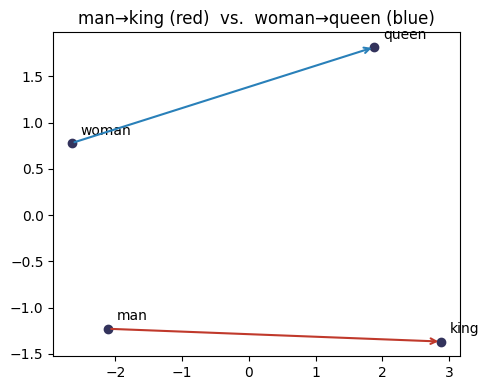

Cosine similarity between the two arrows: 0.968


In [9]:
from sklearn.decomposition import PCA

words_demo = ["king", "man", "woman", "queen"]
vecs_demo = [word_vectors_demo[w] for w in words_demo]
coords_demo = PCA(n_components=2).fit_transform(vecs_demo)

plt.figure(figsize=(5, 4))
for word, (x, y) in zip(words_demo, coords_demo):
    plt.scatter(x, y, color="#33335c")
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(6, 6))

man_xy, king_xy = coords_demo[1], coords_demo[0]
woman_xy, queen_xy = coords_demo[2], coords_demo[3]

plt.annotate("", xy=king_xy, xytext=man_xy,
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.5))
plt.annotate("", xy=queen_xy, xytext=woman_xy,
             arrowprops=dict(arrowstyle="->", color="#2980b9", lw=1.5))

plt.title("man→king (red)  vs.  woman→queen (blue)")
plt.tight_layout()
plt.show()

# Quantify "roughly parallel" with the cosine similarity between the two arrow directions
arrow1 = king_xy - man_xy
arrow2 = queen_xy - woman_xy
cos_between_arrows = np.dot(arrow1, arrow2) / (np.linalg.norm(arrow1) * np.linalg.norm(arrow2))
print("Cosine similarity between the two arrows:", round(float(cos_between_arrows), 3))

The two arrows come out visibly close to parallel (cosine similarity near 1). That closeness *is* the
analogy — `king - man + woman ≈ queen` is just this picture, described with subtraction and addition instead
of arrows. PCA is compressing a 50-dimensional space down to 2D to let us look at it, so don't expect the
arrows to be *perfectly* parallel — some information is necessarily lost in the compression.




Pick two more analogies in the same `positive=[...], negative=[...]` style — for example a country-capital
pair (`paris - france + italy`) or a verb-tense pair — and see whether the top result matches your
expectation.


In [10]:
print(word_vectors_demo.most_similar(positive=["paris", "italy"], negative=["france"], topn=5))

[('rome', 0.8465589284896851), ('milan', 0.7766007781028748), ('turin', 0.7666355967521667), ('venice', 0.7591592073440552), ('madrid', 0.7565805315971375)]


We've now seen the two ends of the spectrum: BoW / one-hot vectors (Part A) that can compare whole
documents but treat every word as unrelated to every other word, and pretrained dense vectors (Part B) that
support rich similarity and arithmetic — but which we didn't train ourselves. **Part C** builds the bridge:
you will train your *own* dense word vectors from scratch, using the CBOW architecture, and see how far a
small amount of training data and compute can get you toward what GloVe achieves at a much larger scale.


## Part C: CBOW Word2Vec from scratch


## 1. From raw text to tokens

We clean the text (lowercase, strip punctuation) and split it into a list of tokens. We'll use a single toy
sentence throughout the rest of this tutorial so every intermediate number is small enough to reason about by
hand.


In [11]:
def clean_text_demo(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_demo(text):
    return text.split()


raw_sentence = "The boy who lived came to die, but the boy who lived came back."
cleaned = clean_text_demo(raw_sentence)
tokens_demo = tokenize_demo(cleaned)

print("Cleaned:", cleaned)
print("Tokens:", tokens_demo)

Cleaned: the boy who lived came to die but the boy who lived came back
Tokens: ['the', 'boy', 'who', 'lived', 'came', 'to', 'die', 'but', 'the', 'boy', 'who', 'lived', 'came', 'back']


## 2. Building the vocabulary

Every distinct token gets an integer id. `word_to_int` and `int_to_word` let us move back and forth between
words and the row/column indices of our weight matrices.


In [12]:
vocab_demo = sorted(set(tokens_demo))
word_to_int_demo = {w: i for i, w in enumerate(vocab_demo)}
int_to_word_demo = {i: w for w, i in word_to_int_demo.items()}

print("Vocab size:", len(vocab_demo))
print(vocab_demo)
print(word_to_int_demo)

Vocab size: 9
['back', 'boy', 'but', 'came', 'die', 'lived', 'the', 'to', 'who']
{'back': 0, 'boy': 1, 'but': 2, 'came': 3, 'die': 4, 'lived': 5, 'the': 6, 'to': 7, 'who': 8}


## 3. Generating (context, target) pairs

For a window size `k`, the target is the word at position `i`; the context is the `k` words to the left and
the `k` words to the right (fewer at the edges of the text — we do **not** pad).

```text
tokens: [the, boy, who, lived, came, to, die]
window_size = 2, i = 2 (target "who")
context = tokens[0:2] + tokens[3:5] = [the, boy] + [lived, came]
        = [the, boy, lived, came]
```


In [13]:
def generate_cbow_pairs_demo(tokens, window_size):
    pairs = []
    n = len(tokens)
    for i in range(n):
        left = tokens[max(0, i - window_size):i]
        right = tokens[i + 1:i + 1 + window_size]
        context = left + right
        pairs.append((context, tokens[i]))
    return pairs


pairs_demo = generate_cbow_pairs_demo(tokens_demo, window_size=2)
for ctx, tgt in pairs_demo[:6]:
    print(ctx, "->", tgt)
print(f"... {len(pairs_demo)} pairs total")

['boy', 'who'] -> the
['the', 'who', 'lived'] -> boy
['the', 'boy', 'lived', 'came'] -> who
['boy', 'who', 'came', 'to'] -> lived
['who', 'lived', 'to', 'die'] -> came
['lived', 'came', 'die', 'but'] -> to
... 14 pairs total


## 4. The CBOW model

CBOW is a one-hidden-layer neural network with **no non-linearity** in the hidden layer and a softmax output.

- `W1` has shape `(vocab_size, embedding_dim)`. Row `W1[i]` is the embedding of word `i`. This is the matrix
  we actually want at the end — it *is* the set of learned word vectors.
- `W2` has shape `(embedding_dim, vocab_size)`. Column `W2[:, j]` is the "output vector" used to score word
  `j` as the predicted target.

### Forward pass

For a set of context word indices $c_1, \dots, c_m$:

$$
\boxed{
h = \frac{1}{m}\sum_{k=1}^{m} W_1[c_k]
}
\qquad\text{(average the context embeddings)}
$$

$$
\boxed{
u = h\, W_2
}
\qquad\text{(score every word in the vocabulary)}
$$

$$
\boxed{
\hat{y} = \mathrm{softmax}(u), \qquad
\hat{y}_j = \frac{e^{u_j}}{\sum_{k} e^{u_k}}
}
$$

`h` is the **hidden layer** — a single embedding-sized vector that summarises the whole context. `y_hat` is a
probability distribution over the vocabulary: the model's guess at the target word.


### Why softmax needs to be numerically stable

If any score in `u` is even moderately large (say 50+), `np.exp(u)` overflows to `inf`, and `inf / inf` becomes
`nan`. The fix is a well-known algebraic identity: subtracting the max score from every entry before
exponentiating **does not change the softmax output** (it cancels in the ratio), but keeps every exponent
`<= 0`, so `np.exp` never overflows.

$$
\mathrm{softmax}(u)_j = \frac{e^{u_j - \max(u)}}{\sum_k e^{u_k - \max(u)}}
$$


In [14]:
def stable_softmax_demo(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


# Compare naive vs. stable softmax on large scores
big_scores = np.array([1000.0, 1001.0, 999.0])

naive = np.exp(big_scores) / np.sum(np.exp(big_scores))
stable = stable_softmax_demo(big_scores)

print("Naive softmax:", naive)   # nan, because exp(1000) overflows
print("Stable softmax:", stable)  # well-behaved probabilities that sum to 1

Naive softmax: [nan nan nan]
Stable softmax: [0.24472847 0.66524096 0.09003057]


/tmp/ipykernel_1964/2384765396.py:10: RuntimeWarning: overflow encountered in exp
  naive = np.exp(big_scores) / np.sum(np.exp(big_scores))
/tmp/ipykernel_1964/2384765396.py:10: RuntimeWarning: invalid value encountered in divide
  naive = np.exp(big_scores) / np.sum(np.exp(big_scores))


In [15]:
def init_params_demo(vocab_size, embedding_dim):
    W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
    W2 = np.random.randn(embedding_dim, vocab_size) * 0.01
    return W1, W2


def forward_demo(context_idxs, W1, W2):
    h = np.mean(W1[context_idxs], axis=0)   # average context embeddings
    u = h @ W2                               # scores over the vocabulary
    y_hat = stable_softmax_demo(u)
    return y_hat, h, u


embedding_dim = 4
W1_demo, W2_demo = init_params_demo(len(vocab_demo), embedding_dim)

context_words, target_word = pairs_demo[2]
context_idxs = [word_to_int_demo[w] for w in context_words]
target_idx = word_to_int_demo[target_word]

y_hat, h, u = forward_demo(context_idxs, W1_demo, W2_demo)

print("Context:", context_words, "-> Target:", target_word)
print("h (hidden vector):", h)
print("y_hat sums to:", y_hat.sum())
print("Model's current probability for the true target:", y_hat[target_idx])

Context: ['the', 'boy', 'lived', 'came'] -> Target: who
h (hidden vector): [ 0.0058634  -0.00414087  0.00576037 -0.00186758]
y_hat sums to: 1.0
Model's current probability for the true target: 0.11110669792785784


Notice `y_hat[target_idx]` is roughly `1 / vocab_size` right now — the weights are random, so the model
has no idea yet which word is correct. Training will push this probability up.


## 5. Loss: Cross-Entropy

For a single training example with true target index $t$:

$$
\boxed{
L = -\log(\hat{y}_t)
}
$$

Because `y_hat` is a probability, `L` is 0 when the model is 100% confident and correct, and grows as the
model assigns less probability to the true word. This is exactly the same cross-entropy loss you have seen in
other classification settings — here the "classes" are the words in the vocabulary.


In [16]:
def cross_entropy_loss_demo(y_hat, target_idx):
    eps = 1e-12  # avoid log(0)
    return -np.log(y_hat[target_idx] + eps)


loss = cross_entropy_loss_demo(y_hat, target_idx)
print("Loss for this example:", loss)
print("(For reference, -log(1/vocab_size) =", -np.log(1 / len(vocab_demo)), "— close, as expected at init)")

Loss for this example: 2.197264296765305
(For reference, -log(1/vocab_size) = 2.1972245773362196 — close, as expected at init)


## 6. Backward pass

We need $\partial L / \partial W_1$ and $\partial L / \partial W_2$. The derivation has three clean steps.

**Step 1 — the softmax + cross-entropy error vector.** A classic and convenient result: when softmax is
paired with cross-entropy loss, the gradient of the loss with respect to the *pre-softmax scores* `u`
simplifies to just the difference between predicted and true distributions:

$$
\boxed{
\frac{\partial L}{\partial u} = e = \hat{y} - y_{true}
}
$$

where $y_{true}$ is the one-hot vector for the target word.

**Step 2 — gradient for `W2`.** Since $u = h W_2$:

$$
\boxed{
\frac{\partial L}{\partial W_2} = h^{\top} e
}
\qquad\text{(outer product of } h \text{ and } e\text{, shape } (\text{embedding\_dim}, \text{vocab\_size}))
$$

**Step 3 — gradient for `W1`.** First get the gradient w.r.t. the hidden vector `h`:

$$
\frac{\partial L}{\partial h} = W_2\, e
$$

Since `h` is the *average* of the context embeddings, this gradient is split equally back to every context
word's row of `W1`:

$$
\boxed{
\frac{\partial L}{\partial W_1[c_k]} \mathrel{+}= \frac{1}{m}\, \frac{\partial L}{\partial h}
\qquad \text{for every context index } c_k
}
$$

All other rows of `W1` (words not in this context) get **zero gradient** from this example.


In [17]:
def backward_demo(y_hat, h, context_idxs, target_idx, W1, W2, vocab_size):
    y_true = np.zeros(vocab_size)
    y_true[target_idx] = 1.0

    e = y_hat - y_true                      # Step 1: softmax + cross-entropy error
    dW2 = np.outer(h, e)                     # Step 2

    dh = W2 @ e                              # gradient w.r.t. hidden vector
    dW1 = np.zeros_like(W1)
    for idx in context_idxs:                 # Step 3: split equally to context rows
        dW1[idx] += dh / len(context_idxs)

    return dW1, dW2


dW1, dW2 = backward_demo(y_hat, h, context_idxs, target_idx, W1_demo, W2_demo, len(vocab_demo))

print("dW1 shape:", dW1.shape, "| dW2 shape:", dW2.shape)
nonzero_rows = np.where(np.any(dW1 != 0, axis=1))[0]
print("Rows of dW1 that received a gradient (should match context word indices):", sorted(nonzero_rows))
print("Context word indices were:", sorted(context_idxs))

dW1 shape: (9, 4) | dW2 shape: (4, 9)
Rows of dW1 that received a gradient (should match context word indices): [np.int64(1), np.int64(3), np.int64(5), np.int64(6)]
Context word indices were: [1, 3, 5, 6]


## 7. One gradient-descent step, by hand

Plain SGD: `W <- W - learning_rate * dW`. Let's take a single step and confirm the loss on this example goes
down — a cheap sanity check you should run on your own implementation before trusting a full training loop.


In [18]:
def sgd_update_demo(W1, W2, dW1, dW2, learning_rate):
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    return W1, W2


learning_rate = 0.5
W1_new, W2_new = sgd_update_demo(W1_demo, W2_demo, dW1, dW2, learning_rate)

y_hat_new, _, _ = forward_demo(context_idxs, W1_new, W2_new)
loss_new = cross_entropy_loss_demo(y_hat_new, target_idx)

print("Loss before update:", loss)
print("Loss after one update:", loss_new)
print("Probability of true target before:", y_hat[target_idx], " after:", y_hat_new[target_idx])

Loss before update: 2.197264296765305
Loss after one update: 2.19721325204478
Probability of true target before: 0.11110669792785784  after: 0.1111123694829523


## 8. The full training loop

Putting it all together: for every epoch, loop over every `(context, target)` pair, run forward &rarr; loss
&rarr; backward &rarr; update, and track the average loss. On our tiny toy sentence, the loss should fall fast
because there are very few distinct examples for the model to memorise.


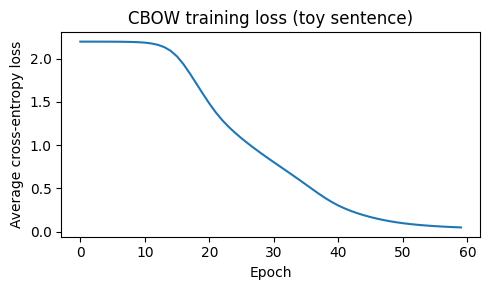

First epoch loss: 2.1972086068575214
Last epoch loss: 0.04749044128778244


In [19]:
def train_demo(pairs, word_to_int, vocab_size, embedding_dim=4,
               learning_rate=0.3, epochs=60):
    W1, W2 = init_params_demo(vocab_size, embedding_dim)
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        for context_words, target_word in pairs:
            context_idxs = [word_to_int[w] for w in context_words]
            target_idx = word_to_int[target_word]

            y_hat, h, u = forward_demo(context_idxs, W1, W2)
            total_loss += cross_entropy_loss_demo(y_hat, target_idx)

            dW1, dW2 = backward_demo(y_hat, h, context_idxs, target_idx, W1, W2, vocab_size)
            W1, W2 = sgd_update_demo(W1, W2, dW1, dW2, learning_rate)

        loss_history.append(total_loss / len(pairs))

    return W1, W2, loss_history


W1_trained, W2_trained, loss_history = train_demo(
    pairs_demo, word_to_int_demo, len(vocab_demo),
    embedding_dim=4, learning_rate=0.3, epochs=60
)

plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW training loss (toy sentence)")
plt.tight_layout()
plt.show()

print("First epoch loss:", loss_history[0])
print("Last epoch loss:", loss_history[-1])

On a real corpus (Harry Potter, in your assignment) you will have far more distinct pairs, so the loss
will fall more slowly and will not reach 0 — that is expected and fine. This toy example is small enough to
essentially memorise, which is exactly why it is useful for **debugging**: if your loss does not fall on a toy
sentence like this, something in your forward/backward pass is wrong, before you even touch the real corpus.


## 9. Evaluation: cosine similarity and nearest neighbours

Once training is done, `W1` holds our word embeddings. To find words with similar meaning/usage, we compare
embedding vectors with **cosine similarity**, which measures the angle between two vectors regardless of their
length:

$$
\boxed{
\cos(v_1, v_2) = \frac{v_1 \cdot v_2}{\lVert v_1 \rVert\, \lVert v_2 \rVert}
}
$$


In [20]:
def cosine_similarity_demo(v1, v2):
    denom = (np.linalg.norm(v1) * np.linalg.norm(v2))
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)


def most_similar_demo(word, W1, word_to_int, int_to_word, top_n=3):
    idx = word_to_int[word]
    query_vec = W1[idx]

    sims = []
    for other_word, other_idx in word_to_int.items():
        if other_word == word:
            continue
        sims.append((other_word, cosine_similarity_demo(query_vec, W1[other_idx])))

    sims.sort(key=lambda pair: pair[1], reverse=True)
    return sims[:top_n]


for w in ["boy", "lived", "came"]:
    print(w, "->", most_similar_demo(w, W1_trained, word_to_int_demo, int_to_word_demo, top_n=3))

boy -> [('to', 0.572661227340291), ('back', 0.4523390464247199), ('die', 0.13086309744903726)]
lived -> [('the', 0.2799597345917144), ('who', 0.020287577812266457), ('but', -0.26898557606476436)]
came -> [('to', 0.5801006799255081), ('back', 0.2799187759409161), ('the', 0.1278194704674779)]


With only one short toy sentence, don't read too much into these particular neighbours — there simply
is not enough data for the model to learn real semantics yet. This cell exists to show you the **mechanics**
of `most_similar`: it is the exact same function you'll write for the assignment, just run here on a corpus
small enough to inspect by eye. On the real Harry Potter corpus with thousands of training pairs, the same
code will start surfacing genuinely related words (e.g. character names near each other, pronouns near each
other).


## Part D: Skip-gram — the mirror image of CBOW

CBOW predicts a target word from its surrounding context (averaging several words into one prediction).
**Skip-gram** flips this around: it predicts each individual context word from a single center/target word.
Everything else — softmax, cross-entropy loss, the general shape of backprop — stays the same. Only the
forward pass and how the gradient reaches `W1` change.


### Generating Skip-gram pairs

Where CBOW produced **one pair per position** (one context list &rarr; one target), Skip-gram produces **one
pair per (position, context word)** — a target with 4 context words yields 4 separate training pairs.


In [21]:
def generate_skipgram_pairs_demo(tokens, window_size):
    pairs = []
    n = len(tokens)
    for i in range(n):
        left = tokens[max(0, i - window_size):i]
        right = tokens[i + 1:i + 1 + window_size]
        context = left + right
        for c in context:
            pairs.append((tokens[i], c))
    return pairs


skipgram_pairs_demo = generate_skipgram_pairs_demo(tokens_demo, window_size=2)
print(f"CBOW pairs from this text:      {len(pairs_demo)}")
print(f"Skip-gram pairs from this text: {len(skipgram_pairs_demo)}")
print()
for center, ctx in skipgram_pairs_demo[:6]:
    print(center, "->", ctx)

CBOW pairs from this text:      14
Skip-gram pairs from this text: 50

the -> boy
the -> who
boy -> the
boy -> who
boy -> lived
who -> the


Notice there are more Skip-gram pairs than CBOW pairs from the exact same tokens — every context word
that used to be bundled into one CBOW example becomes its own separate Skip-gram example.


### Forward pass — actually simpler than CBOW

CBOW had to average multiple context embeddings into one hidden vector. Skip-gram has only **one** input
word, so there's nothing to average:

$$
\boxed{
h = W_1[\text{input\_idx}]
}
\qquad\text{(just the input word's embedding row — no averaging)}
$$

$$
u = h\, W_2, \qquad \hat{y} = \mathrm{softmax}(u)
$$

We reuse the exact same `stable_softmax_demo` from Part C — softmax and its numerical-stability fix don't
care what produced the scores.


In [22]:
def skipgram_forward_demo(input_idx, W1, W2):
    h = W1[input_idx]            # single row, no averaging
    u = h @ W2
    y_hat = stable_softmax_demo(u)
    return y_hat, h, u


center_word, context_word = skipgram_pairs_demo[2]
input_idx = word_to_int_demo[center_word]
context_idx = word_to_int_demo[context_word]

y_hat_sg, h_sg, u_sg = skipgram_forward_demo(input_idx, W1_demo, W2_demo)
print("Input word:", center_word, "-> predicting context word:", context_word)
print("h (just the input word's embedding row):", h_sg)
print("Model's current probability for the true context word:", y_hat_sg[context_idx])

Input word: boy -> predicting context word: the
h (just the input word's embedding row): [ 0.01867558 -0.00977278  0.00950088 -0.00151357]
Model's current probability for the true context word: 0.11106249723725359


### Backward pass — the gradient isn't split

In CBOW, the gradient w.r.t. `h` got divided by the number of context words and spread across all of them,
because `h` was their average. In Skip-gram, `h` came from a **single** word, so that word's row gets the
**entire** gradient, undivided:

$$
e = \hat{y} - y_{true}, \qquad
\nabla W_2 = h^{\top} e, \qquad
\nabla h = W_2\, e
$$

$$
\boxed{
\nabla W_1[\text{input\_idx}] = \nabla h
}
\qquad\text{(the whole gradient — nothing to divide by)}
$$


In [23]:
def skipgram_backward_demo(y_hat, h, input_idx, context_idx, W1, W2, vocab_size):
    y_true = np.zeros(vocab_size)
    y_true[context_idx] = 1.0

    e = y_hat - y_true
    dW2 = np.outer(h, e)

    dh = W2 @ e
    dW1 = np.zeros_like(W1)
    dW1[input_idx] = dh          # entire gradient, no division

    return dW1, dW2


dW1_sg, dW2_sg = skipgram_backward_demo(y_hat_sg, h_sg, input_idx, context_idx, W1_demo, W2_demo, len(vocab_demo))
nonzero_rows_sg = np.where(np.any(dW1_sg != 0, axis=1))[0]
print("Rows of dW1 that received a gradient (should be exactly [input_idx]):", list(nonzero_rows_sg))
print("input_idx was:", input_idx)

Rows of dW1 that received a gradient (should be exactly [input_idx]): [np.int64(1)]
input_idx was: 1


### Training Skip-gram and comparing to CBOW

Same training-loop shape as CBOW, just with `skipgram_forward_demo` / `skipgram_backward_demo` and one
(input, context) pair at a time instead of one (context, target) pair at a time.


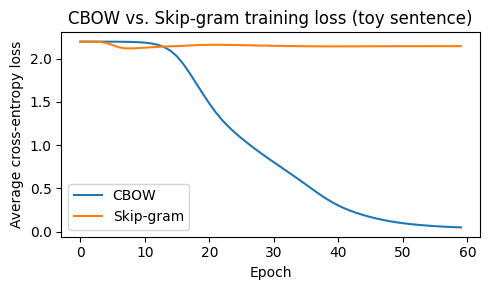

In [24]:
def train_skipgram_demo(pairs, word_to_int, vocab_size, embedding_dim=4,
                         learning_rate=0.3, epochs=60):
    W1, W2 = init_params_demo(vocab_size, embedding_dim)
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        for input_word, context_word in pairs:
            input_idx = word_to_int[input_word]
            context_idx = word_to_int[context_word]

            y_hat, h, u = skipgram_forward_demo(input_idx, W1, W2)
            total_loss += cross_entropy_loss_demo(y_hat, context_idx)

            dW1, dW2 = skipgram_backward_demo(y_hat, h, input_idx, context_idx, W1, W2, vocab_size)
            W1, W2 = sgd_update_demo(W1, W2, dW1, dW2, learning_rate)

        loss_history.append(total_loss / len(pairs))

    return W1, W2, loss_history


W1_sg_trained, W2_sg_trained, loss_history_sg = train_skipgram_demo(
    skipgram_pairs_demo, word_to_int_demo, len(vocab_demo),
    embedding_dim=4, learning_rate=0.3, epochs=60
)

plt.figure(figsize=(5, 3))
plt.plot(loss_history, label="CBOW")
plt.plot(loss_history_sg, label="Skip-gram")
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW vs. Skip-gram training loss (toy sentence)")
plt.legend()
plt.tight_layout()
plt.show()

Look closely — the two curves do **not** behave the same way, and this is a real, expected effect, not
a bug in either implementation:

- **CBOW's** loss falls sharply toward zero. Each of its inputs is an *averaged context vector*, and because
  contexts differ slightly from occurrence to occurrence, CBOW can mostly tell training examples apart and
  nearly memorise this tiny corpus.
- **Skip-gram's** loss stays much higher and barely moves. A frequent word like `"the"` produces the *same*
  input vector every time it appears, but is paired with many different context words across the corpus. The
  model is being asked to predict several different correct answers from one identical input — it cannot do
  better than the entropy of that spread, no matter how long you train.

This is exactly the same one-to-many tension that shows up in real Word2Vec training, just exaggerated by our
tiny, repetitive toy sentence. It's also the mechanism behind Analysis Question Q4 in the assignment: Skip-gram
turns every context slot into its own training example, so on a **large, varied corpus** a rare word (which
doesn't suffer from this many-different-contexts-for-one-input problem nearly as much, since it appears in
far fewer distinct contexts to begin with) tends to get more, cleaner gradient signal per occurrence than it
would under CBOW, where it might just get averaged in alongside more frequent neighbours.


In [25]:
for w in ["boy", "lived", "came"]:
    print(w, "->", most_similar_demo(w, W1_sg_trained, word_to_int_demo, int_to_word_demo, top_n=3))

boy -> [('the', 0.3204801825697396), ('who', 0.31903087988253814), ('came', 0.21034872862865572)]
lived -> [('came', 0.38251963361791064), ('back', 0.2463231553106757), ('who', 0.23741252541693653)]
came -> [('lived', 0.38251963361791064), ('boy', 0.21034872862865572), ('to', 0.0901502871686666)]


Same caveat as Part C's `most_similar` cell: one short toy sentence isn't enough data to judge
embedding quality. This is here to show you the mechanics — the exact same `most_similar` function works on
Skip-gram embeddings as on CBOW embeddings, since both eventually produce a `W1` matrix of the same shape.


## 10. Summary: what you need to build in the assignment

```text
Part A: Bag-of-Words
  -> build_bow_vector, bow_cosine_similarity              (Task A1)
  -> reflection on one-hot orthogonality                  (Task A2)

Part B: Pretrained vectors
  -> load GloVe with gensim, similarity()                 (Task B1)
  -> king - man + woman analogy via most_similar()        (Task B2)
  -> your own analogies                                   (Task B3)
  -> PCA parallelogram visualisation                       (Task B4)

Part C: CBOW from scratch
  raw text
    -> clean_text / tokenize / build_vocab                (Task 1)
    -> generate_cbow_pairs(tokens, window_size)            (Task 2)
    -> init_params, stable_softmax, forward                (Task 3)
    -> cross_entropy_loss, backward, sgd_update             (Task 4)
    -> train: loop over epochs and pairs,                  (Task 5)
       track + plot loss_history
    -> cosine_similarity, most_similar                      (Task 6)
    -> (bonus) PCA scatter plot of your own embeddings      (Task 7)

Part D: Skip-gram from scratch (bonus)
  -> generate_skipgram_pairs(tokens, window_size)          (Task D1)
  -> skipgram_forward (no averaging, reuses stable_softmax) (Task D2)
  -> skipgram_backward (undivided gradient to one row)      (Task D3)
  -> train_skipgram + compare loss/neighbours vs. CBOW       (Task D4)
```

Everything from Section 1 onward in Part C used a single toy sentence with a 4-dimensional embedding so every
array is small enough to print and inspect. In the assignment you will do exactly the same steps, just with:

- a much larger vocabulary (the Harry Potter corpus),
- a larger embedding dimension (e.g. 50 — the same size as the GloVe vectors you played with in Part B),
- many more training pairs and epochs.

The **shapes and formulas do not change** — only the sizes do. If your forward/backward pass is correct here,
scaling it up is mostly a matter of patience (and, if needed, training on a subset of the corpus so the loop
finishes in reasonable time). Don't be discouraged if your Part C embeddings don't show analogies as cleanly
as GloVe did in Part B — GloVe was trained on billions of words; you're training on a small fraction of one
book.
